# Investment Universe Construction
Build the Europe investment universe using firms that are present in returns, emissions, revenues, and market value datasets.

In [44]:
import matplotlib.pyplot as plt

In [45]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path.cwd().parent
CLEAN_DIR = BASE_DIR / "data_clean"
RAW_DIR = BASE_DIR / "data_raw"

In [46]:
returns_non_stale = pd.read_excel(CLEAN_DIR / "returns_monthly_non_stale.xlsx")
scope1_clean = pd.read_excel(CLEAN_DIR / "scope1_clean.xlsx")
scope2_clean = pd.read_excel(CLEAN_DIR / "scope2_clean.xlsx")
revenues_clean = pd.read_excel(CLEAN_DIR / "revenues_clean.xlsx")
mv_year_clean = pd.read_excel(CLEAN_DIR / "market_value_year_clean.xlsx")
static = pd.read_excel(RAW_DIR / "Static_2025.xlsx")

In [47]:
static_europe = static[static["Region"].str.upper() == "EUR"].copy()

print("Firms in Europe:", static_europe.shape[0])

Firms in Europe: 633


In [48]:
isins_europe = set(static_europe["ISIN"])
isins_returns = set(returns_non_stale["ISIN"])
isins_scope1 = set(scope1_clean["ISIN"])
isins_scope2 = set(scope2_clean["ISIN"])
isins_revenues = set(revenues_clean["ISIN"])
isins_mv_year = set(mv_year_clean["ISIN"])

common_isins = (
    isins_europe
    & isins_returns
    & isins_scope1
    & isins_scope2
    & isins_revenues
    & isins_mv_year
)

print("Number of firms in final universe:", len(common_isins))

Number of firms in final universe: 616


In [49]:
returns_final = returns_non_stale[returns_non_stale["ISIN"].isin(common_isins)].copy()
scope1_final = scope1_clean[scope1_clean["ISIN"].isin(common_isins)].copy()
scope2_final = scope2_clean[scope2_clean["ISIN"].isin(common_isins)].copy()
revenues_final = revenues_clean[revenues_clean["ISIN"].isin(common_isins)].copy()
mv_year_final = mv_year_clean[mv_year_clean["ISIN"].isin(common_isins)].copy()
static_final = static_europe[static_europe["ISIN"].isin(common_isins)].copy()

print("returns_final:", returns_final.shape)
print("scope1_final:", scope1_final.shape)
print("scope2_final:", scope2_final.shape)
print("revenues_final:", revenues_final.shape)
print("mv_year_final:", mv_year_final.shape)
print("static_final:", static_final.shape)

returns_final: (616, 316)
scope1_final: (616, 29)
scope2_final: (616, 29)
revenues_final: (616, 29)
mv_year_final: (616, 29)
static_final: (616, 4)


In [50]:
returns_matrix = returns_final.set_index("ISIN").drop(columns=["NAME"]).copy()
returns_matrix.columns = pd.to_datetime(returns_matrix.columns)
returns_matrix.head()

,1999-12-31,2000-01-31,2000-02-29,2000-03-31,2000-04-28,2000-05-31,2000-06-30,2000-07-31,2000-08-31,2000-09-29,...,2025-04-30,2025-05-30,2025-06-30,2025-07-31,2025-08-29,2025-09-30,2025-10-31,2025-11-28,2025-12-31,2026-01-30
ISIN,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.230679,0.001302,0.112875,-0.004401,-0.025746,-0.007655,-0.140520,0.141737,0.063197,0.094270
AT00000VIE62,NaN,0.057243,-0.015488,0.031138,-0.134598,0.085088,0.072038,-0.053858,0.015025,0.054059,...,0.040736,0.013612,0.045520,-0.024938,0.007323,-0.003770,-0.006460,0.051208,0.023005,-0.001547
AT0000606306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.041736,0.143363,-0.004486,-0.041492,0.140807,0.037803,0.082711,0.086321,0.109326,0.128831
AT0000652011,NaN,-0.078007,0.029818,0.028238,-0.043483,0.017996,0.042918,0.003625,0.042859,-0.042221,...,-0.018134,0.241551,0.055130,0.086324,0.032162,0.027326,0.059580,0.054800,0.106051,0.077952
AT0000720008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.135199,0.045852,0.066444,-0.060294,0.029221,-0.024019,-0.003705,-0.028282,0.021079,0.009623


In [51]:
returns_matrix = returns_matrix.dropna(thresh=36)

returns_matrix = returns_matrix.apply(
    lambda row: row.fillna(row.mean()),
    axis=1
)

print(returns_matrix.shape)
returns_matrix.head()

(615, 314)


,1999-12-31,2000-01-31,2000-02-29,2000-03-31,2000-04-28,2000-05-31,2000-06-30,2000-07-31,2000-08-31,2000-09-29,...,2025-04-30,2025-05-30,2025-06-30,2025-07-31,2025-08-29,2025-09-30,2025-10-31,2025-11-28,2025-12-31,2026-01-30
ISIN,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,0.011228,0.011228,0.011228,0.011228,0.011228,0.011228,0.011228,0.011228,0.011228,0.011228,...,0.230679,0.001302,0.112875,-0.004401,-0.025746,-0.007655,-0.140520,0.141737,0.063197,0.094270
AT00000VIE62,0.012403,0.057243,-0.015488,0.031138,-0.134598,0.085088,0.072038,-0.053858,0.015025,0.054059,...,0.040736,0.013612,0.045520,-0.024938,0.007323,-0.003770,-0.006460,0.051208,0.023005,-0.001547
AT0000606306,0.010545,0.010545,0.010545,0.010545,0.010545,0.010545,0.010545,0.010545,0.010545,0.010545,...,0.041736,0.143363,-0.004486,-0.041492,0.140807,0.037803,0.082711,0.086321,0.109326,0.128831
AT0000652011,0.016956,-0.078007,0.029818,0.028238,-0.043483,0.017996,0.042918,0.003625,0.042859,-0.042221,...,-0.018134,0.241551,0.055130,0.086324,0.032162,0.027326,0.059580,0.054800,0.106051,0.077952
AT0000720008,0.007529,0.007529,0.007529,0.007529,0.007529,0.007529,0.007529,0.007529,0.007529,0.007529,...,0.135199,0.045852,0.066444,-0.060294,0.029221,-0.024019,-0.003705,-0.028282,0.021079,0.009623


In [52]:
returns_matrix = returns_matrix.apply(
    lambda row: row.fillna(row.mean()),
    axis=1
)

## 2. Minimum-Variance Portfolio
Compute expected returns, covariance matrix, and the global minimum-variance portfolio.

In [53]:
mu = returns_matrix.mean(axis=1)
Sigma = returns_matrix.T.cov()

lambda_reg = 1e-4
Sigma_reg = Sigma + lambda_reg * np.eye(Sigma.shape[0])

Sigma_inv = np.linalg.inv(Sigma_reg)
ones = np.ones(len(mu))

w_minvar = Sigma_inv @ ones / (ones.T @ Sigma_inv @ ones)

portfolio_return = w_minvar @ mu
portfolio_vol = np.sqrt(w_minvar @ Sigma_reg @ w_minvar)

print("Return:", portfolio_return)
print("Volatility:", portfolio_vol)
print("Sum of weights:", w_minvar.sum())
print("Any NaN weights:", np.isnan(w_minvar).any())

Return: 0.007263819095216084
Volatility: 0.0036128588081228152
Sum of weights: 0.9999999999999992
Any NaN weights: False


In [54]:
print("returns_matrix shape:", returns_matrix.shape)
print("Volatility:", portfolio_vol)
print("Sum of weights:", w_minvar.sum())

returns_matrix shape: (615, 314)
Volatility: 0.0036128588081228152
Sum of weights: 0.9999999999999992


## 3. Minimum-Variance Portfolio (Out-of-Sample)
Rolling estimation using a 10-year window and annual rebalancing.

In [55]:
# Convert columns to datetime
returns_matrix.columns = pd.to_datetime(returns_matrix.columns)

start_year = 2013
end_year = 2024
window = 120  # 10 years of monthly data

portfolio_returns = []
dates = []

for year in range(start_year, end_year + 1):

    end_date = pd.Timestamp(f"{year}-12-31")

    # Get past 120 months
    past_returns = returns_matrix.loc[:, returns_matrix.columns <= end_date].iloc[:, -window:]

    if past_returns.shape[1] < window:
        continue

    # Compute moments
    mu = past_returns.mean(axis=1)
    Sigma = past_returns.T.cov()

    lambda_reg = 1e-4
    Sigma_reg = Sigma + lambda_reg * np.eye(Sigma.shape[0])

    Sigma_inv = np.linalg.inv(Sigma_reg)
    ones = np.ones(len(mu))

    w = Sigma_inv @ ones / (ones.T @ Sigma_inv @ ones)

    # Get next year returns
    next_year = returns_matrix.loc[:, 
        (returns_matrix.columns > end_date) &
        (returns_matrix.columns <= end_date + pd.DateOffset(years=1))
    ]

    for t in next_year.columns:
        r = w @ returns_matrix[t]
        portfolio_returns.append(r)
        dates.append(t)

# Convert to Series
portfolio_returns = pd.Series(portfolio_returns, index=dates)
portfolio_returns.sort_index(inplace=True)

In [56]:
portfolio_returns.shape
portfolio_returns.head()

2014-01-31   -0.025006
2014-02-28    0.012597
2014-03-31   -0.011650
2014-04-30    0.030484
2014-05-30    0.019430
dtype: float64

In [57]:
print("Shape:", portfolio_returns.shape)
portfolio_returns.head()

Shape: (144,)


2014-01-31   -0.025006
2014-02-28    0.012597
2014-03-31   -0.011650
2014-04-30    0.030484
2014-05-30    0.019430
dtype: float64

In [58]:
mean_monthly = portfolio_returns.mean()
vol_monthly = portfolio_returns.std()

mean_annual = mean_monthly * 12
vol_annual = vol_monthly * np.sqrt(12)
sharpe_ratio = mean_annual / vol_annual

print("Minimum-Variance Portfolio (OOS)")
print("Annualized average return:", mean_annual)
print("Annualized volatility:", vol_annual)
print("Sharpe ratio:", sharpe_ratio)
print("Minimum monthly return:", portfolio_returns.min())
print("Maximum monthly return:", portfolio_returns.max())

Minimum-Variance Portfolio (OOS)
Annualized average return: 0.10275400359768849
Annualized volatility: 0.10518757515407175
Sharpe ratio: 0.9768644580615276
Minimum monthly return: -0.09971853433735128
Maximum monthly return: 0.09615029331043254


In [59]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


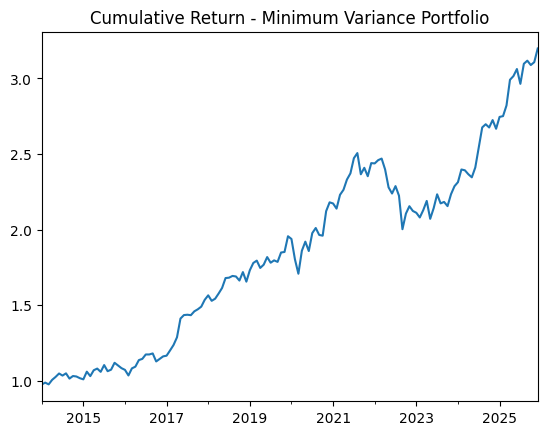

In [60]:
cum_mv = (1 + portfolio_returns).cumprod()
cum_mv.plot(title="Cumulative Return - Minimum Variance Portfolio")
plt.show()

## 4. Value-Weighted Portfolio Benchmark
Construct the value-weighted benchmark portfolio and compare it with the out-of-sample minimum-variance portfolio.

In [75]:
mv_month = pd.read_excel(CLEAN_DIR / "market_value_month_clean.xlsx")
mv_month_final = mv_month[mv_month["ISIN"].isin(common_isins)].copy()

mv_matrix = mv_month_final.set_index("ISIN").drop(columns=["NAME"]).copy()
mv_matrix.columns = pd.to_datetime(mv_matrix.columns)

In [76]:
returns_matrix.index = returns_matrix.index.astype(str).str.strip()
mv_matrix.index = mv_matrix.index.astype(str).str.strip()

common_isins_vw = returns_matrix.index.intersection(mv_matrix.index)
common_dates_vw = returns_matrix.columns.intersection(mv_matrix.columns)

returns_aligned = returns_matrix.loc[common_isins_vw, common_dates_vw].copy()
mv_aligned = mv_matrix.loc[common_isins_vw, common_dates_vw].copy()

returns_aligned = returns_aligned.sort_index(axis=1)
mv_aligned = mv_aligned.sort_index(axis=1)

print("returns_aligned shape:", returns_aligned.shape)
print("mv_aligned shape:", mv_aligned.shape)

returns_aligned shape: (615, 314)
mv_aligned shape: (615, 314)


In [77]:
vw_returns = []
vw_dates = []

dates = list(returns_aligned.columns)

for j in range(1, len(dates)):
    prev_t = dates[j - 1]
    t = dates[j]

    caps = mv_aligned[prev_t]
    rets = returns_aligned[t]

    valid = caps.notna() & rets.notna() & (caps > 0)

    if valid.sum() == 0:
        continue

    weights = caps[valid] / caps[valid].sum()
    r_vw = (weights * rets[valid]).sum()

    vw_returns.append(r_vw)
    vw_dates.append(t)

vw_returns = pd.Series(vw_returns, index=vw_dates)
vw_returns.sort_index(inplace=True)

print("vw_returns shape before OOS restriction:", vw_returns.shape)
vw_returns.head()

vw_returns shape before OOS restriction: (313,)


2000-01-31   -0.067402
2000-02-29    0.051438
2000-03-31    0.030275
2000-04-28   -0.040623
2000-05-31   -0.006961
dtype: float64

In [78]:
portfolio_returns.index = pd.to_datetime(portfolio_returns.index)
vw_returns.index = pd.to_datetime(vw_returns.index)

common_oos_dates = portfolio_returns.index.intersection(vw_returns.index)

portfolio_returns = portfolio_returns.loc[common_oos_dates]
vw_returns = vw_returns.loc[common_oos_dates]

print("portfolio_returns shape:", portfolio_returns.shape)
print("vw_returns shape:", vw_returns.shape)
vw_returns.head()

portfolio_returns shape: (144,)
vw_returns shape: (144,)


2014-01-31   -0.033539
2014-02-28    0.070919
2014-03-31   -0.006968
2014-04-30    0.018132
2014-05-30    0.011860
dtype: float64

In [79]:
print("returns_aligned shape:", returns_aligned.shape)
print("mv_aligned shape:", mv_aligned.shape)
print("portfolio_returns shape:", portfolio_returns.shape)
print("vw_returns shape:", vw_returns.shape)
vw_returns.head()

returns_aligned shape: (615, 314)
mv_aligned shape: (615, 314)
portfolio_returns shape: (144,)
vw_returns shape: (144,)


2014-01-31   -0.033539
2014-02-28    0.070919
2014-03-31   -0.006968
2014-04-30    0.018132
2014-05-30    0.011860
dtype: float64

In [80]:
vw_mean_monthly = vw_returns.mean()
vw_vol_monthly = vw_returns.std()

vw_mean_annual = vw_mean_monthly * 12
vw_vol_annual = vw_vol_monthly * np.sqrt(12)
vw_sharpe = vw_mean_annual / vw_vol_annual

print("Value-Weighted Portfolio")
print("Annualized average return:", vw_mean_annual)
print("Annualized volatility:", vw_vol_annual)
print("Sharpe ratio:", vw_sharpe)
print("Minimum monthly return:", vw_returns.min())
print("Maximum monthly return:", vw_returns.max())

Value-Weighted Portfolio
Annualized average return: 0.0833041220591483
Annualized volatility: 0.1578709742923086
Sharpe ratio: 0.527672185672999
Minimum monthly return: -0.1529878269973451
Maximum monthly return: 0.18238983675391401


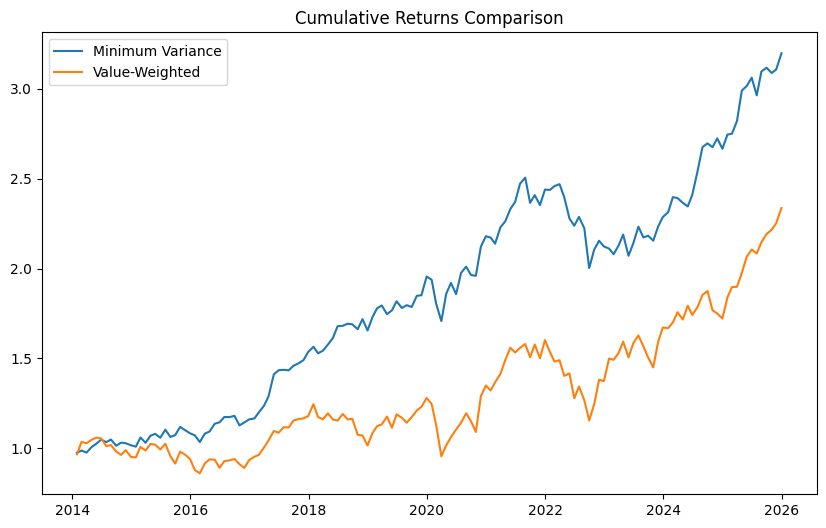

In [81]:
cum_mv = (1 + portfolio_returns).cumprod()
cum_vw = (1 + vw_returns).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(cum_mv.index, cum_mv.values, label="Minimum Variance")
plt.plot(cum_vw.index, cum_vw.values, label="Value-Weighted")
plt.title("Cumulative Returns Comparison")
plt.legend()
plt.show()

In [83]:
print("MV annual return:", mean_annual)
print("MV annual volatility:", vol_annual)
print("MV Sharpe:", sharpe_ratio)

print("VW annual return:", vw_mean_annual)
print("VW annual volatility:", vw_vol_annual)
print("VW Sharpe:", vw_sharpe)

MV annual return: 0.10275400359768849
MV annual volatility: 0.10518757515407175
MV Sharpe: 0.9768644580615276
VW annual return: 0.0833041220591483
VW annual volatility: 0.1578709742923086
VW Sharpe: 0.527672185672999


In [84]:
print(portfolio_returns.min(), portfolio_returns.max())
print(vw_returns.min(), vw_returns.max())

-0.09971853433735128 0.09615029331043254
-0.1529878269973451 0.18238983675391401
